### Lab 3 - Digital Image Representation and Geometric & Intensity Transformations 

## Setup & Imports 📦

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image from the folder
img = cv2.imread('images/input.jpg')
# Convert BGR (OpenCV default) to RGB (Matplotlib default)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"✅ Image loaded! Shape: {img_rgb.shape}")

✅ Image loaded! Shape: (380, 640, 3)


## *Task 1:* Geometric Transformations 📐

In [4]:
rows, cols, ch = img_rgb.shape

# 1️⃣ Scaling: Increase size by 1.5x
scaled = cv2.resize(img_rgb, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LANCZOS4)

# 2️⃣ Rotation: 120 Degrees
matrix_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 120, 1.0)
rotated = cv2.warpAffine(img_rgb, matrix_rot, (cols, rows))

# 3️⃣ Shearing: Tilt the image horizontally
M_shear = np.float32([[1, 0.3, 0], [0, 1, 0]]) 
sheared = cv2.warpAffine(img_rgb, M_shear, (int(cols*1.3), rows))

print("✅ Task 1 Transformations Complete!")

✅ Task 1 Transformations Complete!


## *Task 2:* Intensity Transformations 💡

In [5]:
# 1️⃣ Image Negative
# (No special math needed, just subtract from max intensity)
img_neg = 255 - img_rgb

# 2️⃣ Log Transformation (Your Corrected Code)
img_float = img_rgb.astype(np.float32)
max_pixel_value = np.max(img_float)
c_log = 255 / np.log(1 + max_pixel_value)
log_img = c_log * (np.log(1.0 + img_float))
log_img = np.array(log_img, dtype=np.uint8)

# 3️⃣ Power Law (Gamma) Transformation
# (Uses float to avoid power errors, gamma < 1 increases contrast in darks)
gamma = 0.5
gamma_img = np.array(255 * (img_rgb / 255) ** gamma, dtype=np.uint8)

print("✅ Task 2 Transformations Complete!")

✅ Task 2 Transformations Complete!


## *Visualization* 🎨

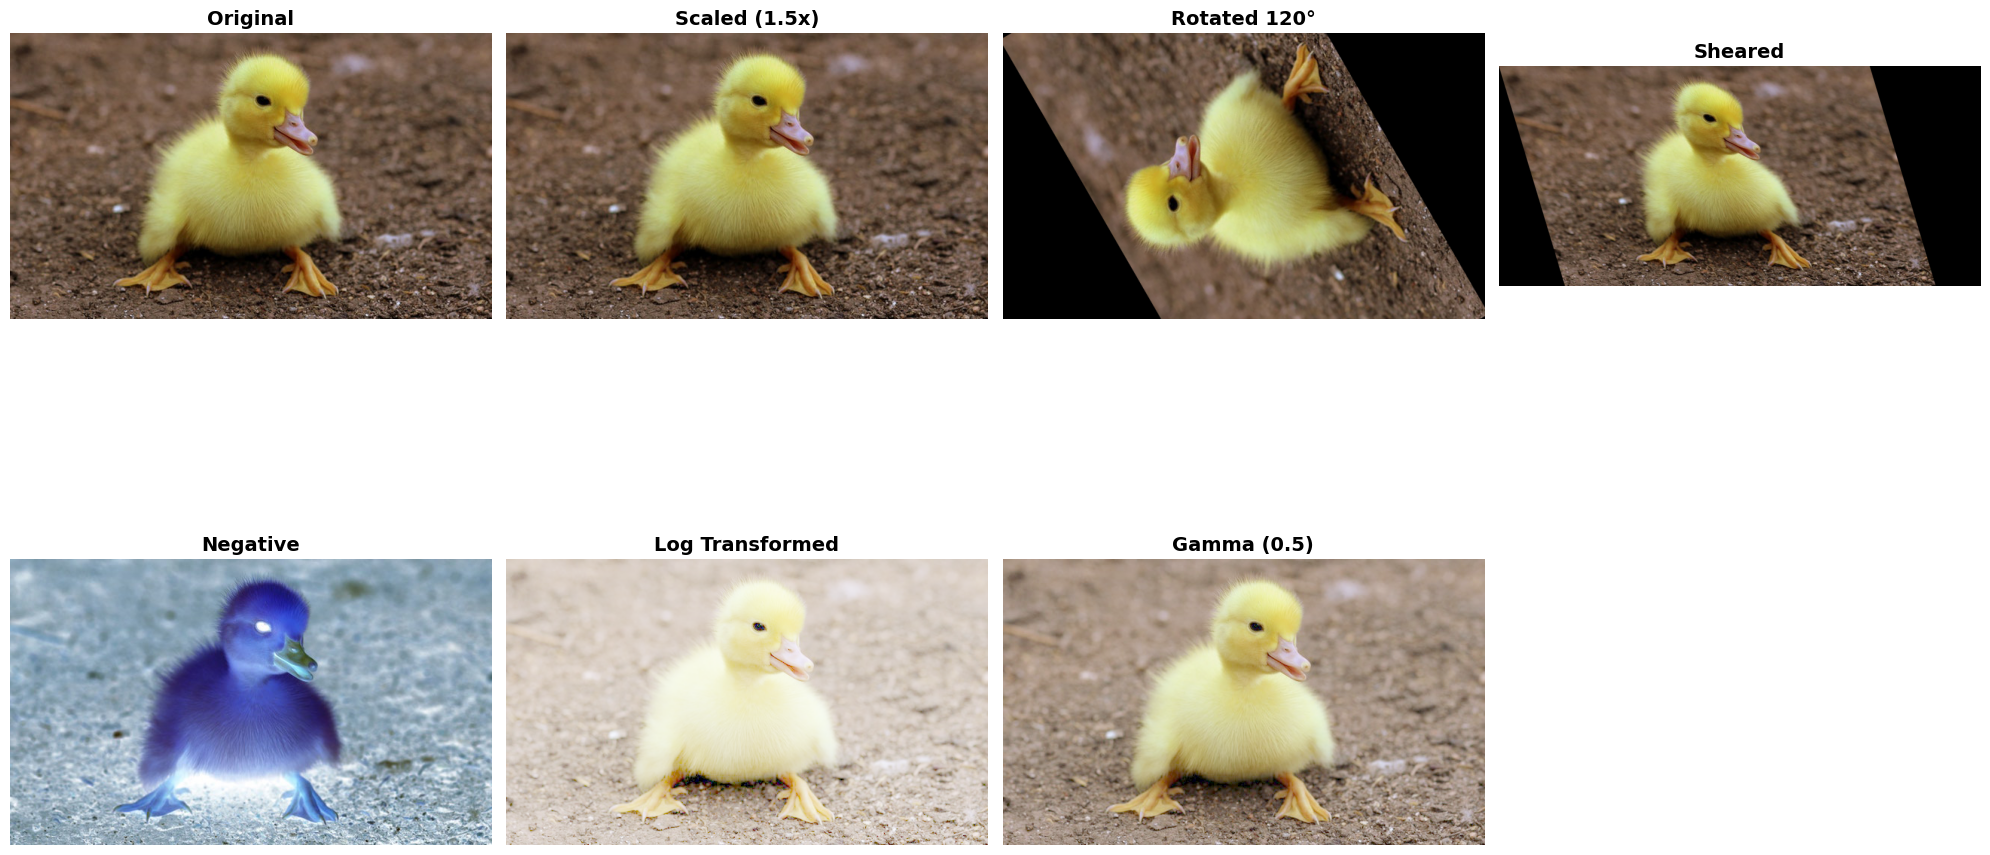

In [6]:
titles = ['Original', 'Scaled (1.5x)', 'Rotated 120°', 'Sheared', 'Negative', 'Log Transformed', 'Gamma (0.5)']
images = [img_rgb, scaled, rotated, sheared, img_neg, log_img, gamma_img]

plt.figure(figsize=(20, 12))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Saving the Results 💾

In [7]:
import os  
import cv2

if not os.path.exists('images'):
    os.makedirs('images')

def save_output(filename, image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(f'images/{filename}', image_bgr)

save_output('output_scaled.jpg', scaled)
save_output('output_rotated.jpg', rotated)
save_output('output_sheared.jpg', sheared)
save_output('output_negative.jpg', img_neg)
save_output('output_log.jpg', log_img)
save_output('output_gamma.jpg', gamma_img)

print("🚀 Success! Check your 'images' folder for the new files.")

🚀 Success! Check your 'images' folder for the new files.
